# Some basic commands to manipulate astronomical fits files

## Import libraries of python

In [1]:
import numpy as np
import os
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

## Reading and writing fits files

HDU = Header Data Unit is the highest level component of the FITS file structure, consisting of a header and (typically) a data array or table.
https://docs.astropy.org/en/stable/io/fits/

In [9]:
path='/content/sample_data/'
file='m27_2025-09-12_21-31-13_Red_0222.fits'
hdu = fits.open(path+file)
im = hdu[0].data #this reads the image
header = hdu[0].header #reads the header

## Printing information on the file and data

In [10]:
print(hdu.info()) # print general information on the file
print(im)  # print the full data array
print(im.shape)   # print the shape of the array
len(header)# print dimension of the header

Filename: /content/sample_data/m27_2025-09-12_21-31-13_Red_0222.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   (1536, 1024)   uint16   
None
[[799 848 830 ... 814 813 782]
 [786 826 854 ... 807 804 804]
 [799 833 822 ... 839 831 802]
 ...
 [909 850 816 ... 829 806 777]
 [914 861 835 ... 823 803 775]
 [908 828 804 ... 790 788 746]]
(1024, 1536)


23

## Printing information on the header

In [11]:
print(header)# print the full header

SIMPLE  =                    T                                                  BITPIX  =                   16                                                  NAXIS   =                    2                                                  NAXIS1  =                 1536                                                  NAXIS2  =                 1024                                                  BZERO   =       32768.00000000                                                  BSCALE  =           1.00000000                                                  EXPTIME =          40.00000000 / seconds                                        EXPOSURE=          40.00000000 / seconds                                        GAIN    =           1.50000000 / e-/ADU                                         XBINNING=                    1                                                  YBINNING=                    1                                                  FILTER  = 'Red     '                    

In [12]:
print(header['DATE-OBS'])
 #print some keywords of the header


2025-09-12T21:30:30.974


## Write a fits file (in this case the same one)

In [14]:
header['OBJECT'] = 'M27'
print(header['OBJECT'])
hdu = fits.PrimaryHDU(data=im,header=header)
hdu.writeto(path+'test.fits',overwrite=True)

M27


# WCS = World Coordinate System
 CRPIX = some reference pixel value
    
 CRVAL = RA and Dec value at pixel CRPIX

 CD1_1 CD1_2 etc. define a matrix that transforms pixel values to RA, Dec values (it basically defines the pixel scale)

See: http://hosting.astro.cornell.edu/~vassilis/isocont/node17.html

In [15]:
wcs = WCS(header)


## Visualize an image

(1024,)
(100,)


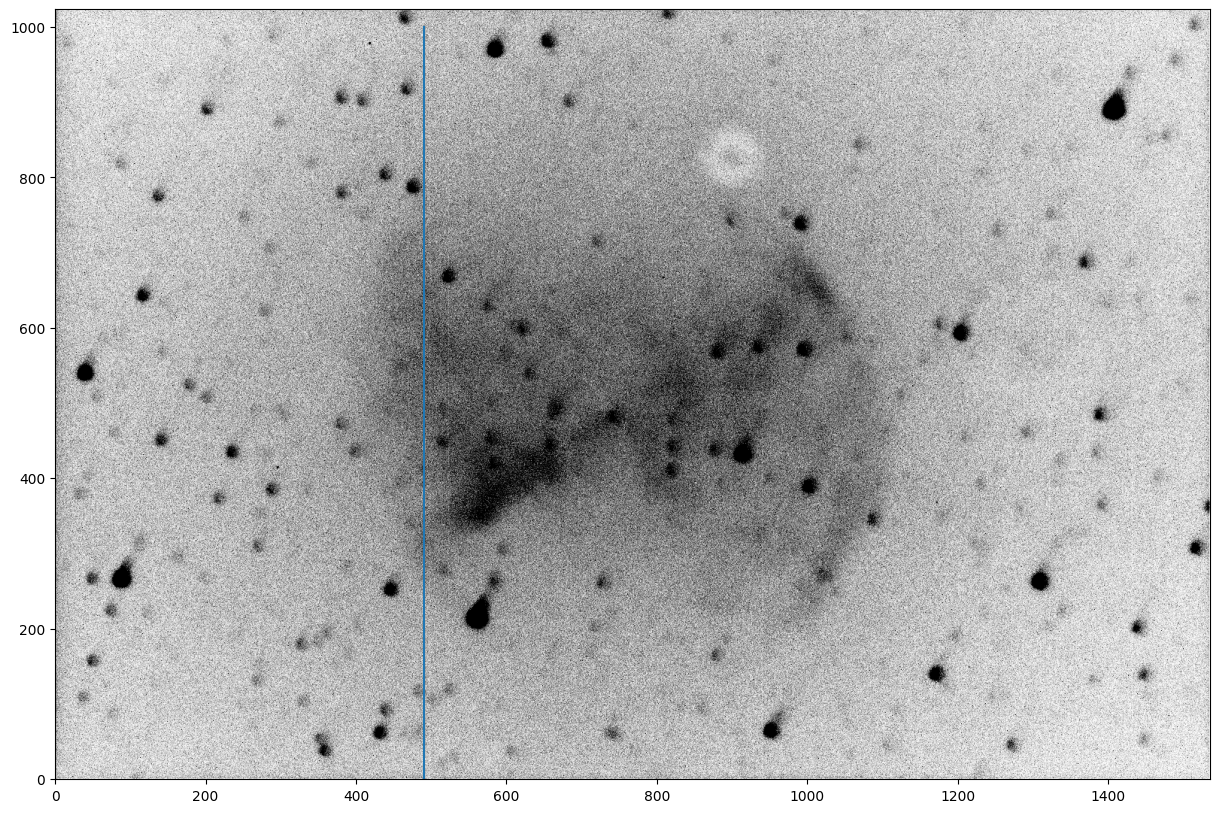

In [16]:
#initialize the figure
fig = plt.figure(figsize=(15,10)) #control the size of the image. You could also define multiple plots in a grid.

#plt.subplot(projection=wcs)

##Plot your image
# Logarithmic scale normally works better than linear (large span of values).
# Control cmin and vmax to getter a better display. It will depend on the image and its values
# cmap defines the color map: https://matplotlib.org/3.1.1/gallery/color/colormap_reference.html
# origin=lower puts the y=0 at the bottom left instead of top left
cmin,cmax = np.percentile(im,1),np.percentile(im,99)
plt.imshow(im,norm=LogNorm(vmin=cmin, vmax=cmax),cmap='Greys', origin='lower')

#I want to plot a vertical cut through a column 490
line=490
cut1=im[:,line] # : means all the rows at this column
print(cut1.shape)
cut2=im[500:600,line] #here only the rows between 500 and 600
print(cut2.shape)
plt.plot([line,line],[0,1000])

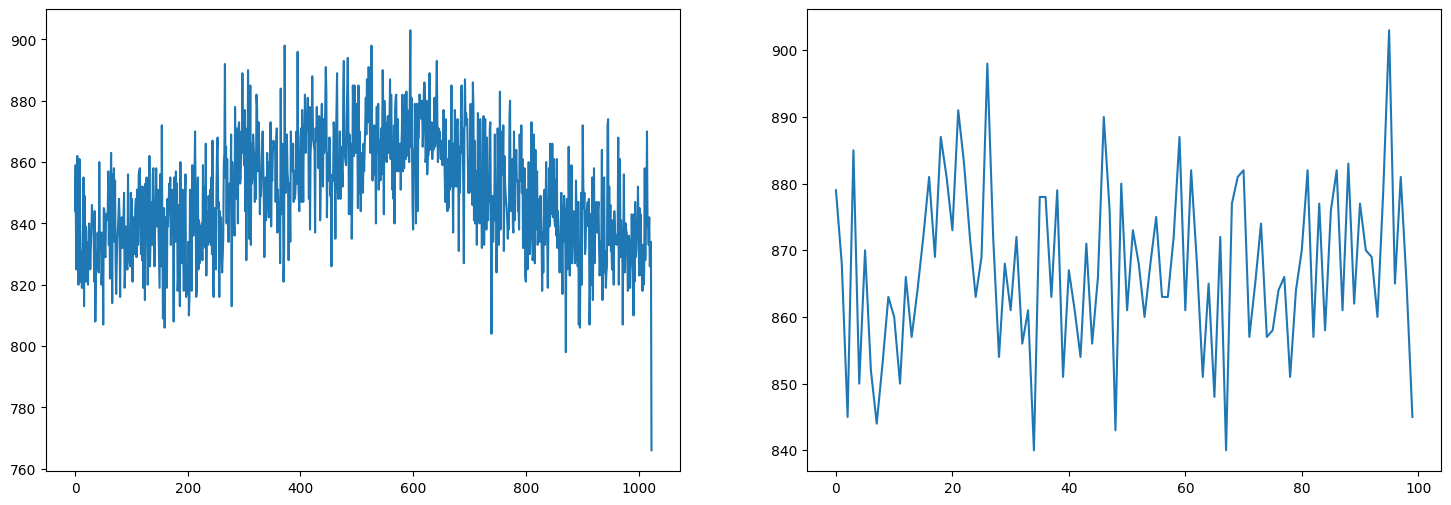

In [17]:
# Plot cuts
nrow=1
ncol=2
fig = plt.figure(figsize=(18*nrow,3*ncol))
ax = fig.add_subplot(nrow,ncol,1)
plt.plot(cut1)
ax = fig.add_subplot(nrow,ncol,2)
plt.plot(cut2)